#### **모두를 위한 딥러닝**
slide
https://drive.google.com/drive/folders/1qVcF8-tx9LexdDT-IY6qOnHc8ekDoL03

git
https://github.com/deeplearningzerotoall/PyTorch?tab=readme-ov-file

youtube
https://www.youtube.com/watch?v=7eldOrjQVi0&list=PLQ28Nx3M4JrhkqBVIXg-i5_CVVoS1UzAv

```bash
docker run --gpus all -it --name pt -p 8888:8888 -p 8097:8097 deeplearningzerotoall/pytorch /bin/bash
```


---

**One-hot Encodig** -> list
- 1만 칸짜리 거대한 종이에 해당 책 번호에만 '1'을 적고 나머지는 다 '0'으로 채운 비효율적인 리스트
- [0, 0, 1, 0, 0,..,0]
- [0, 1, 0, 0, 0,..,0]

**Embedding** -> context vector
- 각 책마다 **'장르', '두께', '출판 연도', '재미'**라는 4개의 핵심 수치를 적어둔 작은 인덱스 카드
- 인덱스 번호만 넘겨주면됨

---

### **RNN (Long sequence)**

- input을 10(0~9번째 글자)으로 잡고 출력은 1번쨰 글자부터 10번째글자까지 순차적으로 예측을 하도록 학습함.

- 즉, 모델은 입력값 10개를 순차적으로 읽으면서 각 위치마다 그다음 글자가 무엇일지 총 10번의 판단을 내리는 구조

In [1]:
import torch
import torch.optim as optim
import numpy as np
torch.manual_seed(0)


In [ ]:
sentence = ("if you want to build a ship, don't drum up people together to "
            "collect wood and don't assign them tasks and work, but rather "
            "teach them to long for the endless immensity of the sea.")

# make dictionary
char_set = list(set(sentence))
char_dic = {c: i for i, c in enumerate(char_set)}

# hyper parameters
dic_size = len(char_dic)
hidden_size = len(char_dic)
sequence_length = 10  # Any arbitrary number 
# 10글자 input하면 한글자씩 총 뒤에 10글자를 예측하도록 함
learning_rate = 0.1

In [4]:

# data setting
x_data = []
y_data = []

for i in range(0, len(sentence) - sequence_length): # 시퀀스 길이를 넘지 않도록
    x_str = sentence[i:i + sequence_length]
    y_str = sentence[i + 1: i + sequence_length + 1]
    print(i, x_str, '->', y_str)

    x_data.append([char_dic[c] for c in x_str])  # x str to index
    y_data.append([char_dic[c] for c in y_str])  # y str to index

x_one_hot = [np.eye(dic_size)[x] for x in x_data]

0 if you wan -> f you want
1 f you want ->  you want 
2  you want  -> you want t
3 you want t -> ou want to
4 ou want to -> u want to 
5 u want to  ->  want to b
6  want to b -> want to bu
7 want to bu -> ant to bui
8 ant to bui -> nt to buil
9 nt to buil -> t to build
10 t to build ->  to build 
11  to build  -> to build a
12 to build a -> o build a 
13 o build a  ->  build a s
14  build a s -> build a sh
15 build a sh -> uild a shi
16 uild a shi -> ild a ship
17 ild a ship -> ld a ship,
18 ld a ship, -> d a ship, 
19 d a ship,  ->  a ship, d
20  a ship, d -> a ship, do
21 a ship, do ->  ship, don
22  ship, don -> ship, don'
23 ship, don' -> hip, don't
24 hip, don't -> ip, don't 
25 ip, don't  -> p, don't d
26 p, don't d -> , don't dr
27 , don't dr ->  don't dru
28  don't dru -> don't drum
29 don't drum -> on't drum 
30 on't drum  -> n't drum u
31 n't drum u -> 't drum up
32 't drum up -> t drum up 
33 t drum up  ->  drum up p
34  drum up p -> drum up pe
35 drum up pe -> rum up peo
36

/tmp/ipykernel_189564/3429064333.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  X = torch.FloatTensor(x_one_hot)


In [10]:
# declare RNN + FC
class Net(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, layers):
        super(Net, self).__init__()
        self.rnn = torch.nn.RNN(input_dim, hidden_dim, num_layers=layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim, hidden_dim, bias=True)

    def forward(self, x):
        x, _status = self.rnn(x)
        x = self.fc(x)
        return x


net = Net(dic_size, hidden_size, 2)

# loss & optimizer setting
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), learning_rate)

In [11]:
# start training
for i in range(100):
    optimizer.zero_grad()
    outputs = net(X)
    loss = criterion(outputs.view(-1, dic_size), Y.view(-1))
    loss.backward()
    optimizer.step()

    results = outputs.argmax(dim=2)
    predict_str = ""
    for j, result in enumerate(results):
        # print(i, j, ''.join([char_set[t] for t in result]), loss.item())
        if j == 0:
            predict_str += ''.join([char_set[t] for t in result])
        else:
            predict_str += char_set[result[-1]]

    print(predict_str)

e ett  ettttt  et etettttetgetg gett f tt e t eeeette ttteet  t  eettet   ett efg gettteeetttttetttt gtttgef  gettttettt t etttt etttett et   et  et tettg eeeeettttgeettt ttttettt
                                                                                                                                                                                   
hhfeohfohhfohyfohyfohyfhhhhhhhhhhhhhhhhfhhhhh..oh.fhhffhhfhhy.hh.fohfeoh.eoh.fohyfehhhhhhhyfhhhhhhhhhhhhhhhhh.eohhhhhhhyfohhhhfhhyfhhfhhhhhhhfhhhfeoyfeohfhhyfhhyfeohhhhhhyfhhhfohf
tttooooottttottonntttttttttttonottttttttottonnnthhttttttttttttonttnhttttntnnntttnottttttttttottttototttttttotttttttttottttttttttttottttotttnnhtttttotttttttnnttttttottttttttotttott
tttoc.etttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttttt
 ttuiid tiiiiiiiiiiiiiiiiiiiiiiiiitiiiiiiiiiiiiiisiiiiiiiiiiisiisiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiiitii

---
### **RNN (timeseries)**

- 시계열 데이터 : 일정한 시간 간격의 데이터
    - Ex. 주식

In [12]:
import torch
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
torch.manual_seed(0)

In [13]:
# scaling function for input data (data 0~1 norm)
def minmax_scaler(data):
    numerator = data - np.min(data, 0)
    denominator = np.max(data, 0) - np.min(data, 0)
    return numerator / (denominator + 1e-7)

# make dataset to input
def build_dataset(time_series, seq_length):
    dataX = []
    dataY = []
    for i in range(0, len(time_series) - seq_length):
        _x = time_series[i:i + seq_length, :]
        _y = time_series[i + seq_length, [-1]]  # Next close price
        print(_x, "->", _y)
        dataX.append(_x)
        dataY.append(_y)
    return np.array(dataX), np.array(dataY)

In [14]:
# hyper parameters
# 주식: 7일짜리의 5가지 데이터를 가지고 1가지의 output: 종가를 계산하도록 함.

seq_length = 7  # 7일
data_dim = 5    # 5가지의 데이터 dim
hidden_dim = 10 
output_dim = 1
learning_rate = 0.01
iterations = 500

In [15]:
# load data
xy = np.loadtxt("data-02-stock_daily.csv", delimiter=",")
xy = xy[::-1]  # reverse order

# split train-test set
train_size = int(len(xy) * 0.7)
train_set = xy[0:train_size]
test_set = xy[train_size - seq_length:]

# scaling data
train_set = minmax_scaler(train_set)
test_set = minmax_scaler(test_set)

# make train-test dataset to input
trainX, trainY = build_dataset(train_set, seq_length)
testX, testY = build_dataset(test_set, seq_length)

# convert to tensor
trainX_tensor = torch.FloatTensor(trainX)
trainY_tensor = torch.FloatTensor(trainY)

testX_tensor = torch.FloatTensor(testX)
testY_tensor = torch.FloatTensor(testY)

[[2.53065030e-01 2.45070970e-01 2.33983036e-01 4.66075110e-04
  2.32039560e-01]
 [2.29604366e-01 2.39728936e-01 2.54567513e-01 2.98467330e-03
  2.37426028e-01]
 [2.49235510e-01 2.41668371e-01 2.48338489e-01 2.59926504e-04
  2.26793794e-01]
 [2.21013495e-01 2.46602231e-01 2.54710584e-01 0.00000000e+00
  2.62668239e-01]
 [3.63433786e-01 3.70389871e-01 2.67168847e-01 1.24764722e-02
  2.62105010e-01]
 [2.59447633e-01 3.10673724e-01 2.74113889e-01 4.56323384e-01
  2.71751265e-01]
 [2.76008150e-01 2.78314566e-01 1.98470380e-01 5.70171193e-01
  1.78104644e-01]] -> [0.16053716]
[[2.29604366e-01 2.39728936e-01 2.54567513e-01 2.98467330e-03
  2.37426028e-01]
 [2.49235510e-01 2.41668371e-01 2.48338489e-01 2.59926504e-04
  2.26793794e-01]
 [2.21013495e-01 2.46602231e-01 2.54710584e-01 0.00000000e+00
  2.62668239e-01]
 [3.63433786e-01 3.70389871e-01 2.67168847e-01 1.24764722e-02
  2.62105010e-01]
 [2.59447633e-01 3.10673724e-01 2.74113889e-01 4.56323384e-01
  2.71751265e-01]
 [2.76008150e-01 2.7831

In [17]:
class Net(torch.nn.Module):
    def __init__(self, input_dim, hidden_diam, output_dim, layers):
        super(Net, self).__init__()
        self.rnn = torch.nn.LSTM(input_dim, hidden_dim, num_layers=layers, batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim, output_dim, bias=True)

    def forward(self, x):
        x, _status = self.rnn(x) # (모든 시점 결과, 마지막 hidden state)
        x = self.fc(x[:, -1]) # 마지막 시점 data만
        return x


net = Net(data_dim, hidden_dim, output_dim, 1)

In [18]:
# loss & optimizer setting
criterion = torch.nn.MSELoss()
optimizer = optim.Adam(net.parameters(), lr=learning_rate)

# start training
for i in range(iterations):

    optimizer.zero_grad()
    outputs = net(trainX_tensor)
    loss = criterion(outputs, trainY_tensor)
    loss.backward()
    optimizer.step()
    print(i, loss.item())

0 0.2271038144826889
1 0.18340934813022614
2 0.15106436610221863
3 0.1261231005191803
4 0.10598734021186829
5 0.08915016800165176
6 0.07493706047534943
7 0.06327900290489197
8 0.05449602007865906
9 0.04902385547757149
10 0.04693441092967987
11 0.04731706529855728
12 0.04838264361023903
13 0.04839477688074112
14 0.046337660402059555
15 0.04207770526409149
16 0.03620168939232826
17 0.029662001878023148
18 0.023386556655168533
19 0.01801123283803463
20 0.013800657354295254
21 0.01071465015411377
22 0.008532215841114521
23 0.0069765071384608746
24 0.005824481137096882
25 0.004987422842532396
26 0.004524713382124901
27 0.0045546842738986015
28 0.005089900456368923
29 0.005920969415456057
30 0.006684894207865
31 0.007072675973176956
32 0.0069739907048642635
33 0.006471904460340738
34 0.00575351994484663
35 0.005014692433178425
36 0.004395292140543461
37 0.003953744191676378
38 0.0036766391713172197
39 0.003510984592139721
40 0.0034013078548014164
41 0.003315107664093375
42 0.0032488943543285

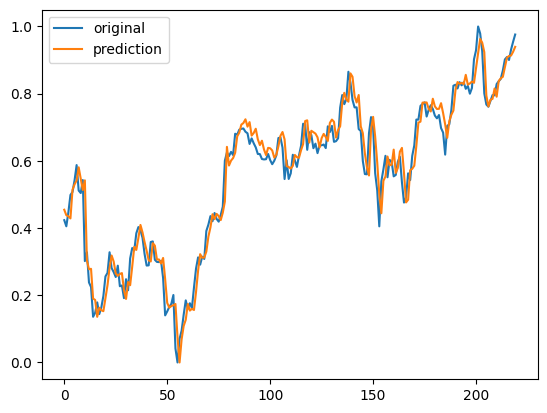

In [19]:
plt.plot(testY)
plt.plot(net(testX_tensor).data.numpy())
plt.legend(['original', 'prediction'])
plt.show()

### **RNN (Seq2Seq); Translation**

- input을 보고 바로 output을 만들기 시작하면 문장의 의미를 모두 담지 못한다
    - 한국말은 끝까지
- 그래서, Encoder-Decoder 구조를 사용
    - Encoder
        - Encoder는 input문장을 모두 다 보고, 하나의 벡터로 요약
        - 마지막 단어까지 읽고 난 후의 최종 hidden state가 문장 전체의 의미
    - Decoder
        - Encoder의 벡터를 받아서 이 목적에 맞는 문장을 생성함\
    

- 아래 예시는 Source Text(English)를 Target Text(Korean)로 번역하도록 하는 모델에 대한 코드

- 입력 데이터: "나는 학교에 간다" + EOS

- 정답 데이터: SOS + "I go to school" + EOS

이렇게 학습시키면 모델은 SOS를 보자마자 I를 말할 준비를 하고, school을 말한 뒤에는 EOS를 내뱉어 스스로 대화를 마무리하는 법을 배우게 됨


In [3]:
import random
import torch
import torch.nn as nn
from torch import optim
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
raw = ["I feel hungry.	나는 배가 고프다.",
       "Pytorch is very easy.	파이토치는 매우 쉽다.",
       "Pytorch is a framework for deep learning.	파이토치는 딥러닝을 위한 프레임워크이다.",
       "Pytorch is very clear to use.	파이토치는 사용하기 매우 직관적이다."]

# fix token for "start of sentence" and "end of sentence"
SOS_token = 0
EOS_token = 1

# class for vocabulary related information of data
class Vocab:
    def __init__(self):
        self.vocab2index = {"<SOS>": SOS_token, "<EOS>": EOS_token}
        self.index2vocab = {SOS_token: "<SOS>", EOS_token: "<EOS>"}
        self.vocab_count = {}
        self.n_vocab = len(self.vocab2index)

    def add_vocab(self, sentence):
        for word in sentence.split(" "):
            if word not in self.vocab2index:
                self.vocab2index[word] = self.n_vocab
                self.vocab_count[word] = 1
                self.index2vocab[self.n_vocab] = word
                self.n_vocab += 1
            else:
                self.vocab_count[word] += 1

# filter out the long sentence from source and target data
def filter_pair(pair, source_max_length, target_max_length):
    return len(pair[0].split(" ")) < source_max_length and len(pair[1].split(" ")) < target_max_length

# read and preprocess the corpus data
def preprocess(corpus, source_max_length, target_max_length):
    print("reading corpus...")
    pairs = []
    for line in corpus:
        pairs.append([s for s in line.strip().lower().split("\t")])
    print("Read {} sentence pairs".format(len(pairs)))

    pairs = [pair for pair in pairs if filter_pair(pair, source_max_length, target_max_length)]
    print("Trimmed to {} sentence pairs".format(len(pairs)))

    source_vocab = Vocab()
    target_vocab = Vocab()

    print("Counting words...")
    for pair in pairs:
        source_vocab.add_vocab(pair[0])
        target_vocab.add_vocab(pair[1])
    print("source vocab size =", source_vocab.n_vocab)
    print("target vocab size =", target_vocab.n_vocab)

    return pairs, source_vocab, target_vocab

In [4]:
# declare simple encoder
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Encoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)  # Dense vector로 압축
        self.gru = nn.GRU(hidden_size, hidden_size) # GRU; LSTM가볍게 만든 버전

    def forward(self, x, hidden):
        x = self.embedding(x).view(1, 1, -1)
        x, hidden = self.gru(x, hidden)
        return x, hidden

In [5]:
# declare simple decoder
class Decoder(nn.Module):
    def __init__(self, hidden_size, output_size):
        super(Decoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, x, hidden):
        x = self.embedding(x).view(1, 1, -1)
        x, hidden = self.gru(x, hidden)
        x = self.softmax(self.out(x[0]))
        return x, hidden

In [8]:
# convert sentence to the index tensor
def tensorize(vocab, sentence):
    indexes = [vocab.vocab2index[word] for word in sentence.split(" ")]
    indexes.append(vocab.vocab2index["<EOS>"])
    return torch.Tensor(indexes).long().to(device).view(-1, 1)
    
# training seq2seq
def train(pairs, source_vocab, target_vocab, encoder, decoder, n_iter, print_every=1000, learning_rate=0.01):
    loss_total = 0

    encoder_optimizer = optim.SGD(encoder.parameters(), lr=learning_rate)
    decoder_optimizer = optim.SGD(decoder.parameters(), lr=learning_rate)

    training_batch = [random.choice(pairs) for _ in range(n_iter)]
    training_source = [tensorize(source_vocab, pair[0]) for pair in training_batch]
    training_target = [tensorize(target_vocab, pair[1]) for pair in training_batch]

    criterion = nn.NLLLoss()

    for i in range(1, n_iter + 1):
        source_tensor = training_source[i - 1]
        target_tensor = training_target[i - 1]

        encoder_hidden = torch.zeros([1, 1, encoder.hidden_size]).to(device)

        encoder_optimizer.zero_grad()
        decoder_optimizer.zero_grad()

        source_length = source_tensor.size(0)
        target_length = target_tensor.size(0)

        loss = 0

        for enc_input in range(source_length):
            _, encoder_hidden = encoder(source_tensor[enc_input], encoder_hidden)

        decoder_input = torch.tensor([[SOS_token]], device=device, dtype=torch.long)
        decoder_hidden = encoder_hidden # connect encoder output to decoder input

        for di in range(target_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            loss += criterion(decoder_output, target_tensor[di])
            decoder_input = target_tensor[di]  # teacher forcing

        loss.backward()

        encoder_optimizer.step()
        decoder_optimizer.step()

        loss_iter = loss.item() / target_length
        loss_total += loss_iter

        if i % print_every == 0:
            loss_avg = loss_total / print_every
            loss_total = 0
            print("[{} - {}%] loss = {:05.4f}".format(i, i / n_iter * 100, loss_avg))

# insert given sentence to check the training
def evaluate(pairs, source_vocab, target_vocab, encoder, decoder, target_max_length):
    for pair in pairs:
        print(">", pair[0])
        print("=", pair[1])
        source_tensor = tensorize(source_vocab, pair[0])
        source_length = source_tensor.size()[0]
        encoder_hidden = torch.zeros([1, 1, encoder.hidden_size]).to(device)

        for ei in range(source_length):
            _, encoder_hidden = encoder(source_tensor[ei], encoder_hidden)

        decoder_input = torch.tensor([[SOS_token]], device=device, dtype=torch.long)
        decoder_hidden = encoder_hidden
        decoded_words = []

        for di in range(target_max_length):
            decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden)
            _, top_index = decoder_output.data.topk(1)
            if top_index.item() == EOS_token:
                decoded_words.append("<EOS>")
                break
            else:
                decoded_words.append(target_vocab.index2vocab[top_index.item()])

            decoder_input = top_index.squeeze().detach()

        predict_words = decoded_words
        predict_sentence = " ".join(predict_words)
        print("<", predict_sentence)
        print("")

In [9]:
# declare max length for sentence
SOURCE_MAX_LENGTH = 10 
TARGET_MAX_LENGTH = 12

# preprocess the corpus
load_pairs, load_source_vocab, load_target_vocab = preprocess(raw, SOURCE_MAX_LENGTH, TARGET_MAX_LENGTH)
print(random.choice(load_pairs))

# declare the encoder and the decoder
enc_hidden_size = 16
dec_hidden_size = enc_hidden_size
enc = Encoder(load_source_vocab.n_vocab, enc_hidden_size).to(device)
dec = Decoder(dec_hidden_size, load_target_vocab.n_vocab).to(device)

# train seq2seq model
train(load_pairs, load_source_vocab, load_target_vocab, enc, dec, 5000, print_every=1000)

# check the model with given data
evaluate(load_pairs, load_source_vocab, load_target_vocab, enc, dec, TARGET_MAX_LENGTH)

reading corpus...
Read 4 sentence pairs
Trimmed to 4 sentence pairs
Counting words...
source vocab size = 17
target vocab size = 13
['pytorch is a framework for deep learning.', '파이토치는 딥러닝을 위한 프레임워크이다.']
[1000 - 20.0%] loss = 0.7128
[2000 - 40.0%] loss = 0.0693
[3000 - 60.0%] loss = 0.0242
[4000 - 80.0%] loss = 0.0143
[5000 - 100.0%] loss = 0.0101
> i feel hungry.
= 나는 배가 고프다.
< 나는 배가 고프다. <EOS>

> pytorch is very easy.
= 파이토치는 매우 쉽다.
< 파이토치는 매우 쉽다. <EOS>

> pytorch is a framework for deep learning.
= 파이토치는 딥러닝을 위한 프레임워크이다.
< 파이토치는 딥러닝을 위한 프레임워크이다. <EOS>

> pytorch is very clear to use.
= 파이토치는 사용하기 매우 직관적이다.
< 파이토치는 사용하기 매우 직관적이다. <EOS>

